<font size="7" color="black"><b>Projeto - Introdução à Ciência de Dados</b></font>

<font size="5" color="black"><b>Natural Language Processing</b></font>

<font size="4">Ano Letivo 2024/2025</font>

<font size="4">**Grupo nº 7**</font>

<br>

| <font size='3'> Nome</font> | <font size='3'> N.º Mec. </font>|
|-----------------------------|---------|
| <font size='3'> Catarina Fernandes </font> | <font size='3'> 102703 </font> |        
| <font size='3'> Isabela Alves </font>     | <font size='3'> 108830</font>  |
| <font size='3'> Fátima Rbaibi</font>     |<font size='3'> 108858 </font> |

In [4]:
import pandas as pd
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import numpy as np
import itertools
import gensim.corpora as corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import seaborn as sns

from sklearn.decomposition import PCA
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk import word_tokenize, pos_tag
from collections import Counter
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from pprint import pprint
from gensim.models import CoherenceModel
from sklearn.cluster import KMeans
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob


# Importação dos dados

In [5]:
# Substituir pelo caminho correto do ficheiro CSV
caminho_ficheiro = "scopus.csv"

# Tente carregar o ficheiro
try:
    df = pd.read_csv(caminho_ficheiro)
    print("Ficheiro CSV carregado com sucesso!")
except FileNotFoundError:
    print(f"Erro: O ficheiro não foi encontrado no caminho especificado: {caminho_ficheiro}")
except Exception as e:
    print(f"Ocorreu um erro ao abrir o ficheiro: {e}")


Erro: O ficheiro não foi encontrado no caminho especificado: scopus.csv


# Compreensão dos dados

In [6]:
# Verificar a formatação do conjunto de dados

df.shape

NameError: name 'df' is not defined

In [83]:
# Visualização das 5 primeiras linhas do dataset
df.head(5)

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Li H.; Hiwatari M.,"Li, Honghui (58933954800); Hiwatari, Masato (5...",58933954800; 57192068316,Unveiling the direct and indirect effects of s...,2024,Humanities and Social Sciences Communications,11,1,391,NaN,...,NaN,NaN,NaN,English,Hum. Soc. Sci. Comm,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-85187524361
1,Jantsch A.; Le Blanc J.; Schmidt T.,"Jantsch, Antje (56763704300); Le Blanc, Julia ...",56763704300; 57190162380; 57203906256,Beyond Income: Exploring the Role of Household...,2024,Journal of Happiness Studies,25,7,101,NaN,...,NaN,NaN,NaN,English,J. Happiness Stud.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-85204929186
2,Fernandes M.I.; Sousa C.; Conde A.R.; Silva F....,"Fernandes, Maria Inês (58750137800); Sousa, Cl...",58750137800; 7006164643; 26535716300; 58750364...,Exploring the Relationship between Capacity to...,2024,Sexuality and Culture,28,4,NaN,1424,...,NaN,NaN,NaN,English,Sex. Cult.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-85178932663
3,Lund L.; Andersen S.; Ritz C.; Bast L.S.,"Lund, Lisbeth (57202196075); Andersen, Susan (...",57202196075; 7201431034; 56441102400; 56174153200,Predicting longitudinal changes in patterns of...,2024,Social Science and Medicine,352,NaN,117029,NaN,...,NaN,SSMDE,38843676.0,English,Soc. Sci. Med.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-85195103333
4,Li Y.; Wang Z.; Zhu Y.,"Li, Yapeng (57818701200); Wang, Zihao (5932988...",57818701200; 59329888800; 59330478800,How Does Government Intervention Affect Commun...,2024,Sustainability (Switzerland),16,17,7326,NaN,...,NaN,NaN,NaN,English,Sustainability,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-85204117306


In [84]:
# Informação acerca do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2165 entries, 0 to 2164
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Authors                        2162 non-null   object 
 1   Author full names              2162 non-null   object 
 2   Author(s) ID                   2162 non-null   object 
 3   Title                          2165 non-null   object 
 4   Year                           2165 non-null   int64  
 5   Source title                   2165 non-null   object 
 6   Volume                         2145 non-null   object 
 7   Issue                          1809 non-null   object 
 8   Art. No.                       666 non-null    object 
 9   Page start                     1487 non-null   object 
 10  Page end                       1479 non-null   object 
 11  Page count                     1480 non-null   float64
 12  Cited by                       2165 non-null   i

In [85]:
# Visualizar os nomes das colunas
df.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Page count', 'Cited by', 'DOI', 'Link', 'Affiliations',
       'Authors with affiliations', 'Abstract', 'Author Keywords',
       'Index Keywords', 'Molecular Sequence Numbers', 'Chemicals/CAS',
       'Tradenames', 'Manufacturers', 'Funding Details', 'Funding Texts',
       'References', 'Correspondence Address', 'Editors', 'Publisher',
       'Sponsors', 'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID'],
      dtype='object')

# **1. Limpeza dos dados**

## 1.1. Verificação e remoção de duplicados

In [86]:
# Verificar a existência de valores duplicados

if df.duplicated().sum() == 0:
    print("Não há valores duplicados no DataFrame.")
else:
    print(f"Existem {df.duplicated().sum()} valores duplicados no DataFrame.")


Não há valores duplicados no DataFrame.


In [87]:
# Verificar a existência de duplicados na coluna Abstract

duplicate = df['Abstract'].duplicated().sum()
if duplicate == 0:
    print("Não há valores duplicados na coluna Abstract.")
else:
    print(f"Existem {duplicate} valores duplicados na coluna Abstract.")

Existem 2 valores duplicados na coluna Abstract.


In [88]:
# Remoção das linhas duplicadas

df = df.drop_duplicates(subset=['Abstract'])
df.shape

(2163, 46)

## 1.2. Verificação da existência de *missing values*

In [89]:
df.isna().sum()

Authors                             3
Author full names                   3
Author(s) ID                        3
Title                               0
Year                                0
Source title                        0
Volume                             20
Issue                             355
Art. No.                         1498
Page start                        677
Page end                          684
Page count                        683
Cited by                            0
DOI                                 0
Link                                0
Affiliations                        9
Authors with affiliations           9
Abstract                            0
Author Keywords                   122
Index Keywords                   1091
Molecular Sequence Numbers       2162
Chemicals/CAS                    2142
Tradenames                       2153
Manufacturers                    2156
Funding Details                  1084
Funding Texts                    1172
References  

# **2. Pré-processamento do texto**

## 2.1. Conversão do texto para minúsculas

In [90]:
# Conversão de todos os caracteres para mínusculas
df_normalizado = df.apply(lambda x: x.astype(str).str.lower())
df_normalizado.head(3)

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,li h.; hiwatari m.,"li, honghui (58933954800); hiwatari, masato (5...",58933954800; 57192068316,unveiling the direct and indirect effects of s...,2024,humanities and social sciences communications,11,1,391,nan,...,nan,nan,nan,english,hum. soc. sci. comm,article,final,all open access; gold open access,scopus,2-s2.0-85187524361
1,jantsch a.; le blanc j.; schmidt t.,"jantsch, antje (56763704300); le blanc, julia ...",56763704300; 57190162380; 57203906256,beyond income: exploring the role of household...,2024,journal of happiness studies,25,7,101,nan,...,nan,nan,nan,english,j. happiness stud.,article,final,all open access; hybrid gold open access,scopus,2-s2.0-85204929186
2,fernandes m.i.; sousa c.; conde a.r.; silva f....,"fernandes, maria inês (58750137800); sousa, cl...",58750137800; 7006164643; 26535716300; 58750364...,exploring the relationship between capacity to...,2024,sexuality and culture,28,4,nan,1424,...,nan,nan,nan,english,sex. cult.,article,final,all open access; hybrid gold open access,scopus,2-s2.0-85178932663


## 2.2. Remoção de URL's

In [91]:
# Função para remover URLs

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

# Aplicar a função à coluna 'Abstract'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract'].apply(remove_urls)



## 2.3. Remoção de tags HTML

In [92]:
# Função para remover tags HTML

def remove_html_tags(text):
    return re.sub(r'<.*?>', '', text)

# Aplicar a função à coluna 'Abstract'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract'].apply(remove_html_tags)



## 2.4. Remoção de pontuação e caracteres especiais

In [93]:
# Função para remover pontuação e caracteres especiais
def remove_punctuation_special_chars(text):
    return re.sub(r'[^\w\s]', '', text)

# Aplicar a função à coluna 'abstract'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract_Clean'].apply(remove_punctuation_special_chars)

# Exibir as primeiras linhas para verificar o resultado
old_text = df_normalizado.loc[0, 'Abstract']
new_text = df_normalizado.loc[0, 'Abstract_Clean']
print("old -\t", old_text)
print("new -\t", new_text)

old -	 as china grapples with the dual policy challenges of declining birth rates and the pursuit of individual happiness, understanding the relationship between these two factors is important. this study empirically examined the influence of sibling size on happiness in china, distinguishing between direct and indirect channels of impact. using data from the 2008 chinese general social survey, this analysis focused on how sibling size shapes individual income and education levels, which are both key determinants of happiness. it addressed the endogeneity issue inherent in sibling size by employing variations in the implementation of family planning policies across provinces in the 1970s as instrumental variables. the findings revealed an indirect relationship between sibling size and happiness; an increase in sibling size negatively affected both income and education levels, subsequently reducing happiness. this study contributes to the ongoing dialogue on the relationship between fam

## 2.5. Remoção de stopwords

### 2.5.1. Remoção das stopwords padrão

In [94]:
stop_words = set(stopwords.words('english'))

# Função para remover stopwords de uma coluna de texto em um DataFrame
def remove_stopwords(text):
    words = text.split()  # Dividir o texto em palavras
    return " ".join(word for word in words if word.lower() not in stop_words)

# Aplicar a remoção de stopwords na coluna 'Abstract'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract_Clean'].apply(remove_stopwords)

novo_texto = df_normalizado.loc[0, 'Abstract_Clean']

print("new -\t", novo_texto)


new -	 china grapples dual policy challenges declining birth rates pursuit individual happiness understanding relationship two factors important study empirically examined influence sibling size happiness china distinguishing direct indirect channels impact using data 2008 chinese general social survey analysis focused sibling size shapes individual income education levels key determinants happiness addressed endogeneity issue inherent sibling size employing variations implementation family planning policies across provinces 1970s instrumental variables findings revealed indirect relationship sibling size happiness increase sibling size negatively affected income education levels subsequently reducing happiness study contributes ongoing dialogue relationship family size individual happiness china offering nuanced insights channels effects occur study also highlights policy implications suggesting initiatives raise birth rate accompanied efforts enhance income educational opportunities 

### 2.5.2. Remoção das palavras mais raras

In [95]:
# Remover palavras raras da coluna 'Abstract_Clean'
def remove_rare_words(text):
    if pd.isna(text):
        return ""
    word_counts = Counter(text.split())
    rare_words = [word for word, count in word_counts.items() if count == 1]
    return ' '.join([word for word in text.split() if word not in rare_words])

# Aplicar remoção de palavras raras na coluna 'Abstract_Clean'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract_Clean'].apply(remove_rare_words)

### 2.5.3. Remoção de palavras curtas

In [96]:
# Remover palavras com 2 ou menos caracteres na coluna 'Abstract_Clean'
def remove_short_words(text):
    if pd.isna(text):
        return ""
    return ' '.join([word for word in text.split() if len(word) > 2])

df_normalizado['Abstract_Clean'] = df_normalizado['Abstract_Clean'].apply(remove_short_words)

### 2.5.4. Determinar as palavras mais frequentes

In [97]:
# Concatenar todos os textos da coluna 'Abstract_Clean'
all_text = " ".join(df_normalizado['Abstract_Clean'])

# Dividir o texto em palavras com base em espaços (sem tokenização explícita)
words = all_text.split()  # Apenas divide por espaços

# Contar a frequência de cada palavra
word_counts = Counter(words)

# Mostrar as 20 palavras mais frequentes
most_common_words = word_counts.most_common(50)
print("Palavras mais frequentes:")
for word, freq in most_common_words:
    print(f"{word}: {freq}")



Palavras mais frequentes:
satisfaction: 3675
life: 3481
wellbeing: 2498
study: 2190
social: 1752
health: 1662
happiness: 1659
factors: 1286
students: 1258
research: 894
emotional: 799
results: 784
positive: 690
subjective: 689
analysis: 651
among: 634
data: 633
psychological: 613
support: 609
relationship: 608
quality: 571
mental: 560
associated: 555
scale: 534
school: 512
older: 504
work: 485
age: 453
significant: 448
model: 437
perceived: 429
level: 427
adults: 426
levels: 425
effects: 422
stress: 415
family: 413
people: 405
children: 397
higher: 384
negative: 370
job: 368
adolescents: 357
physical: 356
women: 342
using: 341
participants: 340
swb: 330
education: 325
use: 323


### 2.5.5. Atualizar a lista de stopwords

In [98]:
# Lista de stopwords em inglês (NLTK)
stop_words = set(stopwords.words('english'))

# Adicionar as novas stopwords à lista de stopwords padrão
new_stopwords = [
    'satisfaction', 'life', 'wellbeing', 'study', 'factors', 'happiness', 'results',
    'research', 'data', 'analysis', 'positive', 'among', 'using', 'significant', 
    'associated', 'findings', 'also', 'model', 'effects', 'used', 'scale', 
    'levels', 'level', 'survey', 'factor', 'studies', 'years', 'people', 'participants', 'child', 'social', 'quality', 'mental', 'care', 'support',
    'identity', 'psychological', 'individual', 'older', 'country', 'change', 'association', 'neighbourhood', 'higher', 'swb', 'use', 'groups', 'activity', 
    'qol', 'group', 'public', 'affect','subjective', 'measures', 'measure', 'participation', 'emotional', 'perceived', 'students',
    'individuals', 'activities', 'activity', 'negative', 'symptoms', 'patients', 'patient', 'health',
    'high', 'adults', 'schools', 'women', 'men', 'residents',  'time', 'related', 'validity', 
    'information', 'paper', 'capital', 'girls', 'physical', 'medical', 'burnout', 'reported', 'relationships', 'associantions', 
    'chronic', 'effect', 'assessment', 'forgive', 'adolecents', 'domains', 'substance', 'urban',
    'less', 'european', 'perception'
    ]
stop_words.update(new_stopwords)
 
# Função para remover stopwords combinadas de uma coluna de texto em um DataFrame
def remove_stopwords(text):
    words = text.split()  # Dividir o texto em palavras
    return " ".join(word for word in words if word.lower() not in stop_words)

# Aplicar a remoção de stopwords na coluna 'Abstract_Clean'
df_normalizado['Abstract_Clean'] = df_normalizado['Abstract_Clean'].apply(remove_stopwords)

# Exibir o resultado para a primeira linha
novo_texto = df_normalizado.loc[0, 'Abstract_Clean']
print("new -\t", novo_texto)


new -	 china policy birth relationship sibling size china indirect channels sibling size income education sibling size family indirect relationship sibling size sibling size income education relationship family size china channels policy birth income


## 2.6. Tokenização

In [99]:
# Função para tokenizar o texto
def tokenize_text(text):
    return nltk.word_tokenize(text)

# Aplicar a tokenização à coluna 'Abstract_Clean'
df_normalizado['Abstract_Tokens'] = df_normalizado['Abstract_Clean'].apply(tokenize_text)

# Exibir o resultado para a primeira linha
tokens = df_normalizado.loc[0, 'Abstract_Tokens']
print("Tokens:\t", tokens)


Tokens:	 ['china', 'policy', 'birth', 'relationship', 'sibling', 'size', 'china', 'indirect', 'channels', 'sibling', 'size', 'income', 'education', 'sibling', 'size', 'family', 'indirect', 'relationship', 'sibling', 'size', 'sibling', 'size', 'income', 'education', 'relationship', 'family', 'size', 'china', 'channels', 'policy', 'birth', 'income']


## 2.7. Remoção de números

In [100]:
# Função para remover números de uma lista de tokens
def remove_numbers_from_tokens(tokens):
    return [token for token in tokens if not token.isdigit()]  # Filtra tokens que são números

# Aplicar a função à coluna 'Abstract_Tokens' (após tokenização)
df_normalizado['Abstract_Tokens_NoNumbers'] = df_normalizado['Abstract_Tokens'].apply(remove_numbers_from_tokens)

# Exibir o resultado para a primeira linha
tokens_sem_numeros = df_normalizado.loc[0, 'Abstract_Tokens_NoNumbers']
print("Tokens sem números -\t", tokens_sem_numeros)


Tokens sem números -	 ['china', 'policy', 'birth', 'relationship', 'sibling', 'size', 'china', 'indirect', 'channels', 'sibling', 'size', 'income', 'education', 'sibling', 'size', 'family', 'indirect', 'relationship', 'sibling', 'size', 'sibling', 'size', 'income', 'education', 'relationship', 'family', 'size', 'china', 'channels', 'policy', 'birth', 'income']


## 2.8. Lematização

In [101]:
# Inicializar o lemmatizer
lemmatizer = WordNetLemmatizer()

# Função para lematizar os tokens
def lemmatize_tokens_nltk(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]  # Lematizar cada token

# Aplicar a lematização nos tokens da coluna 'Abstract_Tokens'
df_normalizado['Abstract_Lemmatized'] = df_normalizado['Abstract_Tokens_NoNumbers'].apply(lemmatize_tokens_nltk)

# Exibir o resultado para a primeira linha
lematized_tokens = df_normalizado.loc[0, 'Abstract_Lemmatized']
print("Tokens lematizados -\t", lematized_tokens)


Tokens lematizados -	 ['china', 'policy', 'birth', 'relationship', 'sibling', 'size', 'china', 'indirect', 'channel', 'sibling', 'size', 'income', 'education', 'sibling', 'size', 'family', 'indirect', 'relationship', 'sibling', 'size', 'sibling', 'size', 'income', 'education', 'relationship', 'family', 'size', 'china', 'channel', 'policy', 'birth', 'income']


In [102]:

df_normalizado['Abstract_Expanded'] = df_normalizado['Abstract_Lemmatized'].apply(lambda words: ' '.join(words))


## 2.9. Criação de um novo dataframe

In [103]:
# Conversão dos valores da coluna Abstract_Lemmatized em strings
df_normalizado["Abstract_Lemmatized"] = df_normalizado["Abstract_Lemmatized"].astype(str)

In [104]:
selected_columns = df_normalizado[['Abstract', 'Abstract_Clean', 'Abstract_Lemmatized', 'Abstract_Expanded']]
selected_columns.head(20)

,Abstract,Abstract_Clean,Abstract_Lemmatized,Abstract_Expanded
0,as china grapples with the dual policy challen...,china policy birth relationship sibling size c...,"['china', 'policy', 'birth', 'relationship', '...",china policy birth relationship sibling size c...
1,an individual's financial situation positively...,financial situation literature income financia...,"['financial', 'situation', 'literature', 'inco...",financial situation literature income financia...
2,love is a complex construct of undeniable impo...,love complex human capacity love capacity comp...,"['love', 'complex', 'human', 'capacity', 'love...",love complex human capacity love capacity comp...
3,introduction: understanding factors influencin...,influencing transition nonuse tobacco nicotine...,"['influencing', 'transition', 'nonuse', 'tobac...",influencing transition nonuse tobacco nicotine...
4,the traditional model of community public serv...,community government openness communities gove...,"['community', 'government', 'openness', 'commu...",community government openness community govern...
5,"background: due to climate change, the increas...",heat heat strain healthcare hcw particularly e...,"['heat', 'heat', 'strain', 'healthcare', 'hcw'...",heat heat strain healthcare hcw particularly e...
6,background: the psychosocial impact of medical...,marijuana evaluated changes hrqol three months...,"['marijuana', 'evaluated', 'change', 'hrqol', ...",marijuana evaluated change hrqol three month m...
7,"nearly 28,000 children, ranging from kindergar...",mainland china hong kong crossborder hong kong...,"['mainland', 'china', 'hong', 'kong', 'crossbo...",mainland china hong kong crossborder hong kong...
8,the spatial clustering of life satisfaction sc...,scores happier may specific questions happier ...,"['score', 'happier', 'may', 'specific', 'quest...",score happier may specific question happier mo...
9,couple burnout has been linked to several nega...,couple couple interventions relationship selfe...,"['couple', 'couple', 'intervention', 'relation...",couple couple intervention relationship selfef...


In [105]:
# Guardar o DataFrame normalizado em um novo ficheiro CSV
# caminho_ficheiro_normalizado = "novo_scopus.csv"
# selected_columns.to_csv(caminho_ficheiro_normalizado, index=False)

## 3. Wordcloud

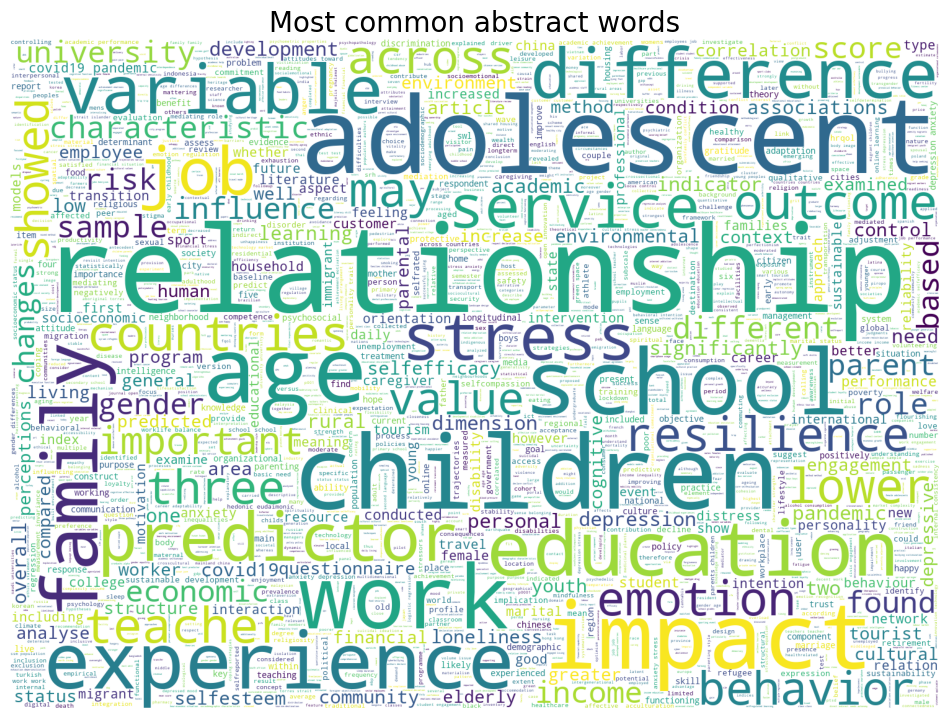

In [106]:

plt.subplots(figsize=(12,10))
wordcloud = WordCloud(
                          background_color='white',max_words = 10000, width=1500, stopwords=stop_words,
                          height=1080).generate(" ".join(df_normalizado["Abstract_Clean"]))
plt.title("Most common abstract words", fontsize=20)
plt.imshow(wordcloud.recolor( colormap= 'viridis'))
plt.axis('off')
plt.show()

# **4. Processamento avançado do texto**

## 4.1. Bag of Words

In [107]:
# Inicializar o CountVectorizer
vectorizer = CountVectorizer()

# Ajustar e transformar os dados 
X = vectorizer.fit_transform(df_normalizado['Abstract_Lemmatized'])

# Converter a matriz para um DataFrame
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Exibir as 10 primeiras linhas do DataFrame
bow_df

,10th,10yearold,12month,12yearsold,15d,15yearold,18item,1990s,24item,2factor,...,zbi,zealand,zefs,zhang,zhejiang,zone,zoom,δnccs,η²p,χ2df
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2160,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.1.1. Gráfico para os Bag of Words mais comuns

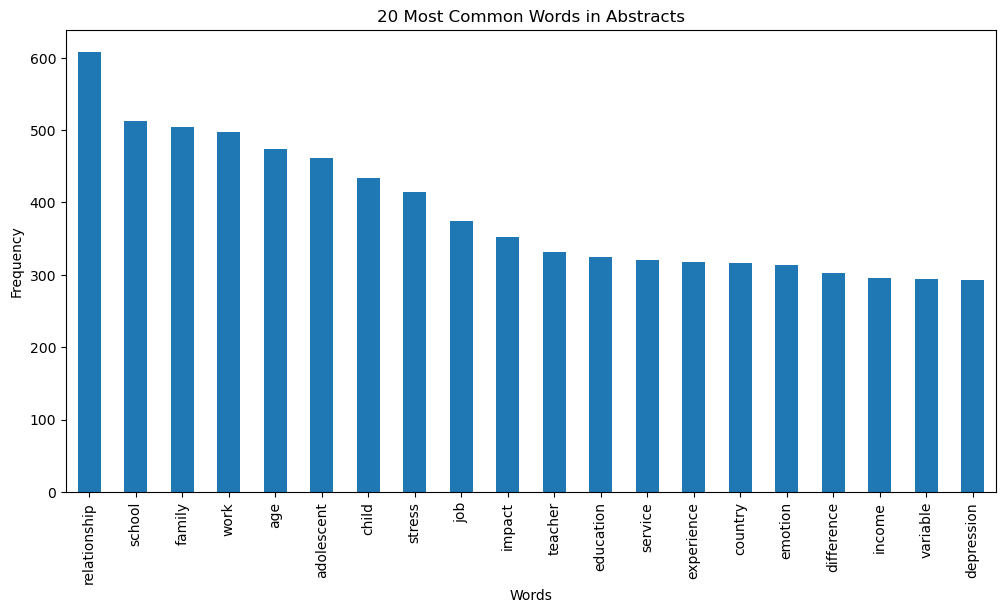

In [108]:
# Somar a contagem de cada palavra
word_counts = bow_df.sum()

# Ordenar e selecionar as 20 palavras mais frequentes
most_common_words = word_counts.sort_values(ascending=False).head(20)

# Exibir as palavras mais frequentes num gráfico de barras
plt.figure(figsize=(12, 6))
most_common_words.plot(kind='bar')
plt.title("20 Most Common Words in Abstracts")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

### 4.1.2. WordCloud para os BoW mais comuns

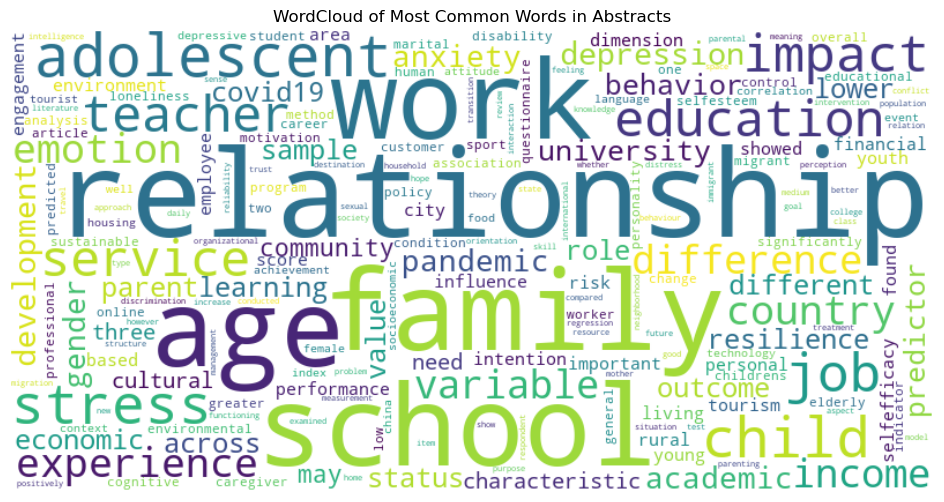

In [109]:
# Gerar a WordCloud para os BoW mais frequentes
wordcloud = WordCloud(width = 800, height = 400, background_color='white').generate_from_frequencies(word_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Most Common Words in Abstracts")
plt.show()

## 4.2. Análise de Bigramas

In [110]:
# Inicializa o CountVectorizer com o parâmetro de bigramas
vectorizer = CountVectorizer(ngram_range=(2, 2))  # Para bigramas

# Ajusta e transforma os dados
X = vectorizer.fit_transform(df_normalizado['Abstract_Lemmatized'])

# Converte para array e, em seguida, para DataFrame para melhor visualização
ngram_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Exibição
ngram_df

,10th 10th,10th complete,10yearold child,12month disorder,12yearsold gender,12yearsold nine,15d angina,15d eq5d5l,15d saq,15yearold country,...,zone risk,zone spatial,zone zone,zoom exhaustion,zoom facetoface,zoom learning,δnccs lonelinesscognition,δnccs partially,η²p label,χ2df tli
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2159,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2160,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2161,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.2.1. Gráfico para os bigramas mais comuns

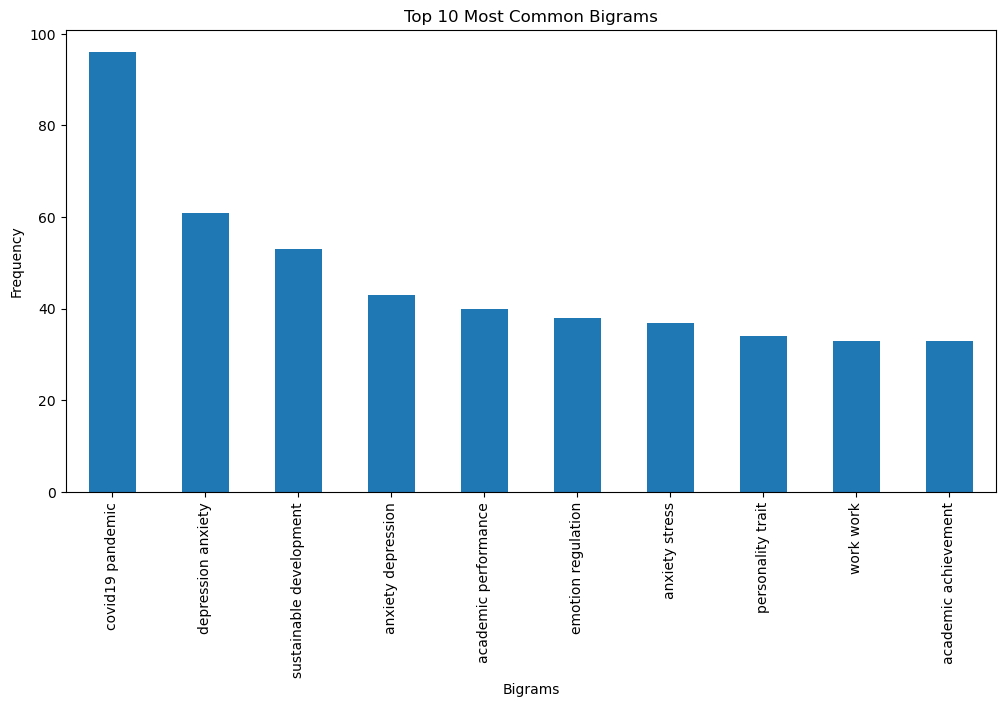

In [111]:
# Soma a contagem de cada bigrama
sum_bigrams = ngram_df.sum(axis=0)

# Ordena e seleciona os 10 bigramas mais comuns
sorted_bigrams = sum_bigrams.sort_values(ascending=False)[:10]

# Exibe os bigramas mais comuns num gráfico de barras
plt.figure(figsize=(12, 6))
sorted_bigrams.plot(kind='bar')
plt.title('Top 10 Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.show()

### 4.2.2. WordCloud para os bigramas mais comuns

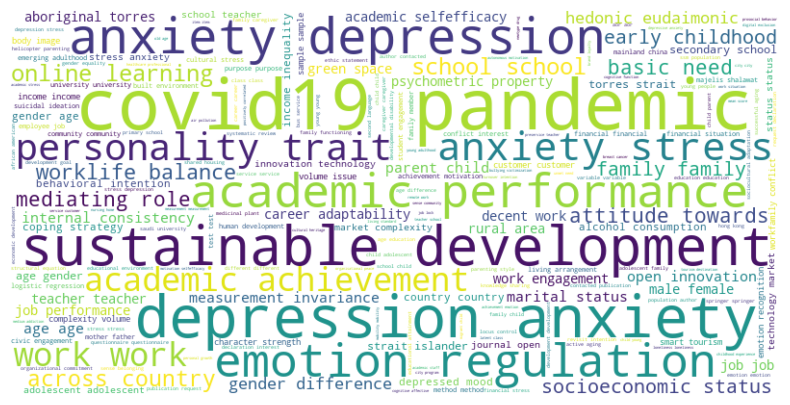

In [112]:
# Gera a WordCloud para os bigramas mais frequentes
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(sum_bigrams)

# Exibe a WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 4.3. Term Frequency-Inverse Document Frequency (TF-IDF)

In [113]:
# Inicializa o TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Ajusta e transforma os dados
tfidf_matrix = tfidf_vectorizer.fit_transform(df_normalizado['Abstract_Lemmatized'])

# Converte a matriz para um DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Exibição
tfidf_df

,10th,10yearold,12month,12yearsold,15d,15yearold,18item,1990s,24item,2factor,...,zbi,zealand,zefs,zhang,zhejiang,zone,zoom,δnccs,η²p,χ2df
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.3.1. Gráfico com as 10 palavras com maior TF-IDF

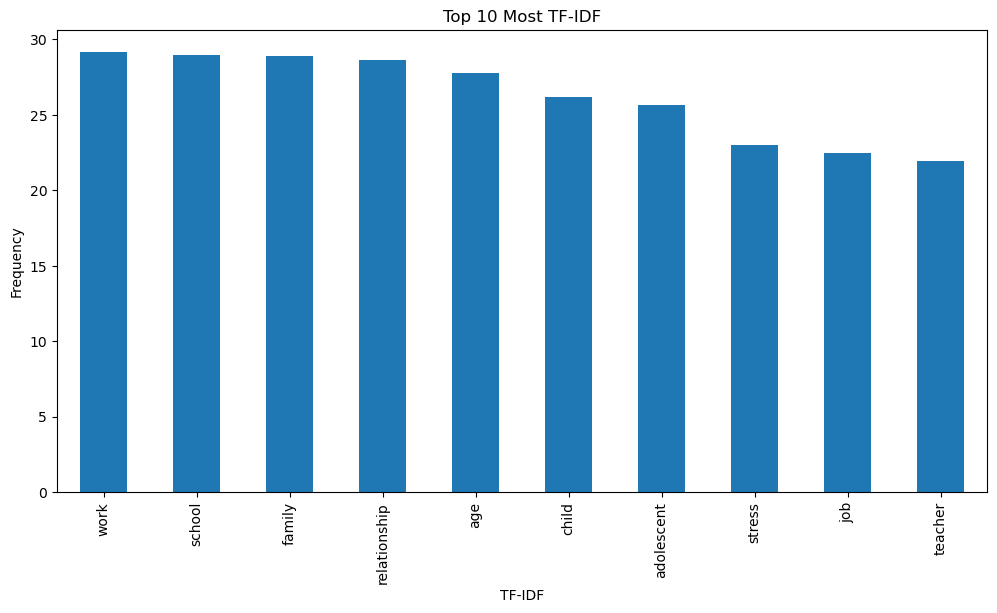

In [114]:
# Soma o TF-IDF de cada palavra
sum_tfidf = tfidf_df.sum(axis=0)

# Ordena e seleciona as 10 palavras com maior TF-IDF
sorted_tfidf = sum_tfidf.sort_values(ascending=False)[:10]

# Exibe as palavras com maior TF-IDF num gráfico de barras
plt.figure(figsize=(12, 6))
sorted_tfidf.plot(kind='bar')
plt.title('Top 10 Most TF-IDF')
plt.xlabel('TF-IDF')
plt.ylabel('Frequency')
plt.show()

### 4.3.3. WordCloud para as palavras com maior TF-IDF

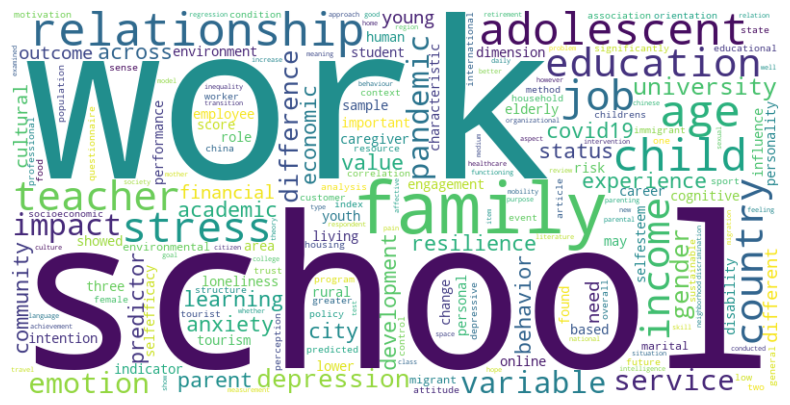

In [115]:
# Gera a WordCloud para as palavras com maior TF-IDF
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(sum_tfidf)

# Exibe a WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


## 4.4. TF-IDF para bigramas

In [116]:
# Inicializar o TfidfVectorizer para bigramas
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2))

# Ajustar e transformar os dados lematizados
tfidf_bigram_matrix = tfidf_bigram_vectorizer.fit_transform(df_normalizado['Abstract_Expanded'])

# Converter a matriz para um DataFrame para visualização
tfidf_bigram_df = pd.DataFrame(tfidf_bigram_matrix.toarray(), columns=tfidf_bigram_vectorizer.get_feature_names_out())

# Exibir as 10 primeiras linhas do DataFrame
tfidf_bigram_df

,10th 10th,10th complete,10yearold child,12month disorder,12yearsold gender,12yearsold nine,15d angina,15d eq5d5l,15d saq,15yearold country,...,zone risk,zone spatial,zone zone,zoom exhaustion,zoom facetoface,zoom learning,δnccs lonelinesscognition,δnccs partially,η²p label,χ2df tli
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.4.1. Gráfico com os 10 bigramas com maior TF-IDF

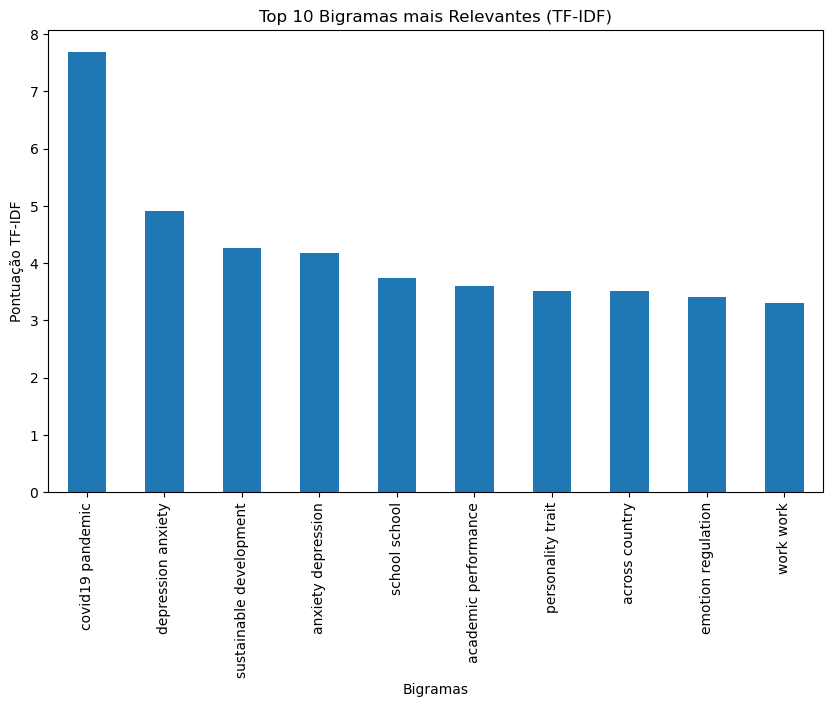

In [117]:
# Calcular a soma dos valores TF-IDF para cada bigrama
bigram_scores = tfidf_bigram_df.sum().sort_values(ascending=False)

# Plotar os 10 bigramas mais relevantes
bigram_scores.head(10).plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Bigramas mais Relevantes (TF-IDF)')
plt.xlabel('Bigramas')
plt.ylabel('Pontuação TF-IDF')
plt.show()


### 4.4.2. WordCloud dos bigramas com maior TF-IDF

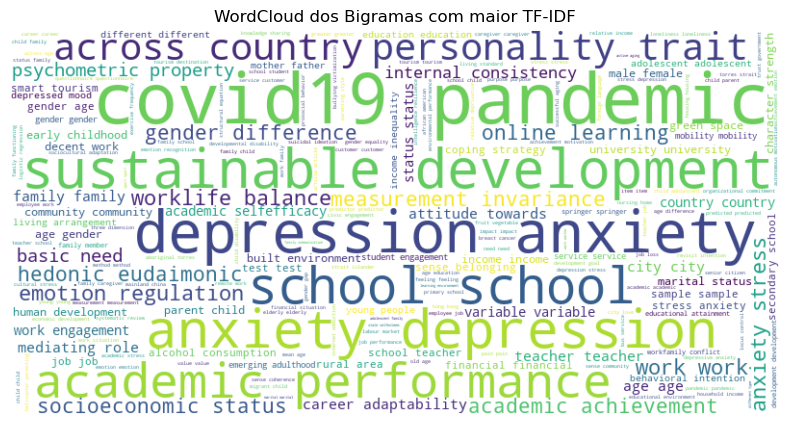

In [118]:
# Calcula a soma dos valores TF-IDF para cada bigrama
sum_tfidf_bigrams = tfidf_bigram_df.sum().to_dict()

# Gera a WordCloud para os bigramas com maior TF-IDF
wordcloud_bigrams = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(sum_tfidf_bigrams)

# Exibe a WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_bigrams, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud dos Bigramas com maior TF-IDF', fontsize=12)
plt.show()

## 4.5. Part of Speech (POS) Tagging

In [119]:
# Retirar as aspas simples
df_normalizado['Abstract_Lemmatized'] = df_normalizado['Abstract_Expanded'].apply(lambda x: re.sub(r"'", "", x)) 

In [120]:
# Função para aplicar POS tagging a uma frase
def pos_tag_sentence(sentence):
    tokens = word_tokenize(sentence)
    return pos_tag(tokens)

# Aplicar POS tagging à coluna 'Abstract_Expanded'
df_normalizado['POS_Tagged_Abstract'] = df_normalizado['Abstract_Expanded'].apply(pos_tag_sentence)

# Exibir o resultado
df_normalizado[['Abstract_Expanded', 'POS_Tagged_Abstract']].head()


,Abstract_Expanded,POS_Tagged_Abstract
0,china policy birth relationship sibling size c...,"[(china, NN), (policy, NN), (birth, NN), (rela..."
1,financial situation literature income financia...,"[(financial, JJ), (situation, NN), (literature..."
2,love complex human capacity love capacity comp...,"[(love, NN), (complex, NN), (human, JJ), (capa..."
3,influencing transition nonuse tobacco nicotine...,"[(influencing, VBG), (transition, NN), (nonuse..."
4,community government openness community govern...,"[(community, NN), (government, NN), (openness,..."


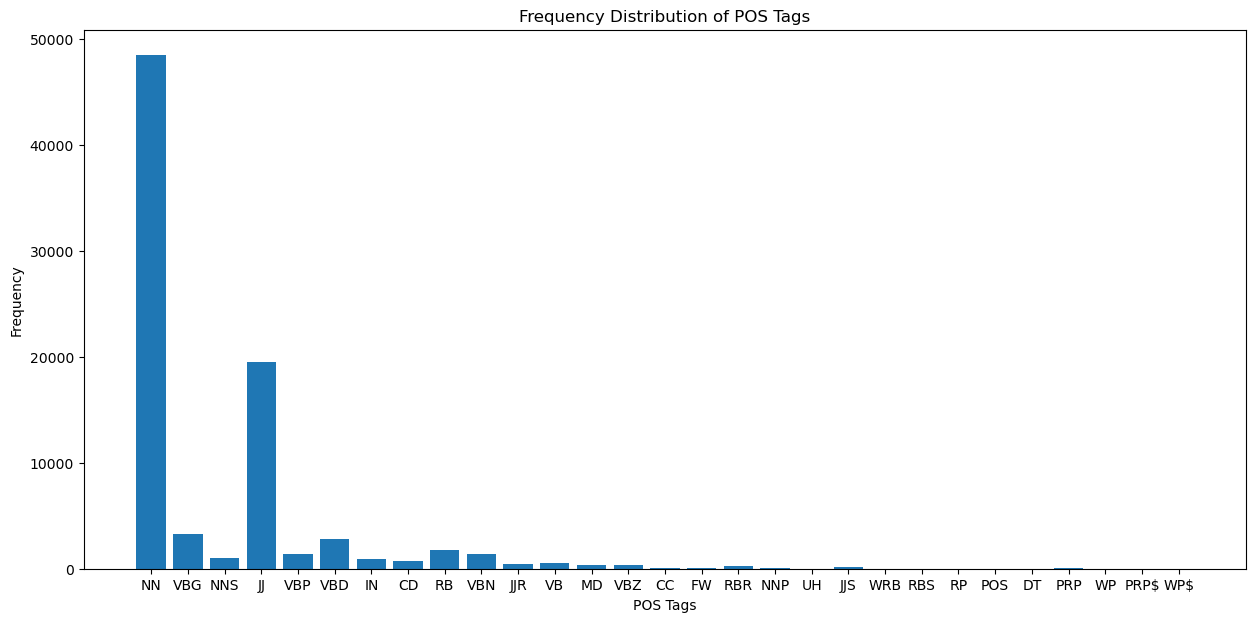

In [121]:
# Extrair todos os POS tags
all_tags = list(itertools.chain.from_iterable(df_normalizado['POS_Tagged_Abstract'].apply(lambda x: [tag for word, tag in x])))

# Contar a frequência de cada POS tag
tag_freq = Counter(all_tags)

# Exibir a distribuição de frequência dos POS tags
plt.figure(figsize=(15, 7))
plt.bar(tag_freq.keys(), tag_freq.values())
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of POS Tags')
plt.show()

In [122]:
# Exibir a distribuição de frequência dos POS tags
df_normalizado[['Abstract_Expanded', 'POS_Tagged_Abstract']].head()

,Abstract_Expanded,POS_Tagged_Abstract
0,china policy birth relationship sibling size c...,"[(china, NN), (policy, NN), (birth, NN), (rela..."
1,financial situation literature income financia...,"[(financial, JJ), (situation, NN), (literature..."
2,love complex human capacity love capacity comp...,"[(love, NN), (complex, NN), (human, JJ), (capa..."
3,influencing transition nonuse tobacco nicotine...,"[(influencing, VBG), (transition, NN), (nonuse..."
4,community government openness community govern...,"[(community, NN), (government, NN), (openness,..."


### 4.5.2. POS tags mais relevantes para o tema

Adjetivos

[('variable', 282), ('academic', 276), ('pandemic', 252), ('economic', 220), ('different', 215), ('cultural', 211), ('characteristic', 207), ('financial', 191), ('personal', 188), ('important', 185)]


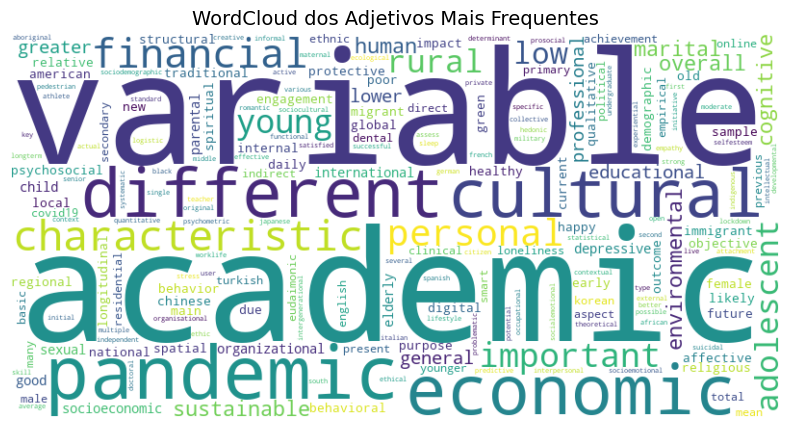

In [123]:
# Identificar os adjetivos
adjective_words = [word for abstract in df_normalizado['POS_Tagged_Abstract'] for word, tag in abstract if tag.startswith('JJ')]

# Contar frequência dos adjetivos
adjective_freq = Counter(adjective_words)

# Exibir os 10 adjetivos mais comuns
print(adjective_freq.most_common(10))

# WordCloud para adjetivos
wordcloud_adjectives = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(adjective_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_adjectives, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud dos Adjetivos Mais Frequentes', fontsize=14)
plt.show()


Substantivos

[('relationship', 608), ('school', 512), ('family', 504), ('work', 485), ('age', 474), ('stress', 377), ('job', 374), ('education', 321), ('service', 318), ('child', 317)]


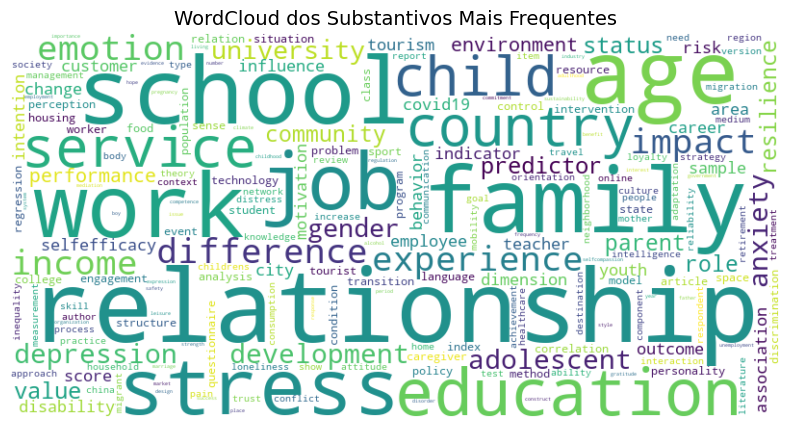

In [124]:
# Identificar os substantivos
noun_words = [word for abstract in df_normalizado['POS_Tagged_Abstract'] for word, tag in abstract if tag.startswith('NN')]

# Contar frequência dos substantivos
noun_freq = Counter(noun_words)

# Exibir os 10 substantivos mais comuns
print(noun_freq.most_common(10))

# WordCloud para substantivos
wordcloud_nouns = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(noun_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_nouns, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud dos Substantivos Mais Frequentes', fontsize=14)
plt.show()


Verbos

[('learning', 199), ('showed', 183), ('based', 169), ('found', 164), ('predicted', 126), ('living', 122), ('compared', 102), ('examined', 102), ('need', 96), ('conducted', 92)]


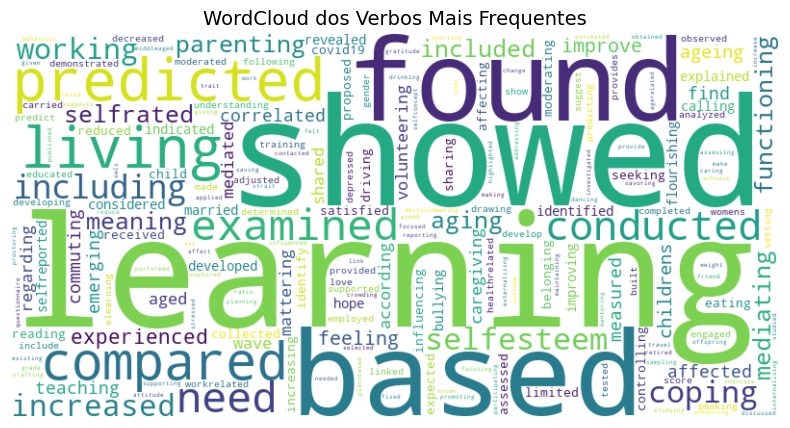

In [125]:
# identificar os verbos
verb_words = [word for abstract in df_normalizado['POS_Tagged_Abstract'] for word, tag in abstract if tag.startswith('VB')]

# Contar a frequência dos verbos
verb_freq = Counter(verb_words)

# Exibir os 10 verbos mais comuns
print(verb_freq.most_common(10))

# WordCloud para verbos
wordcloud_verbs = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(verb_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_verbs, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud dos Verbos Mais Frequentes', fontsize=14)
plt.show()


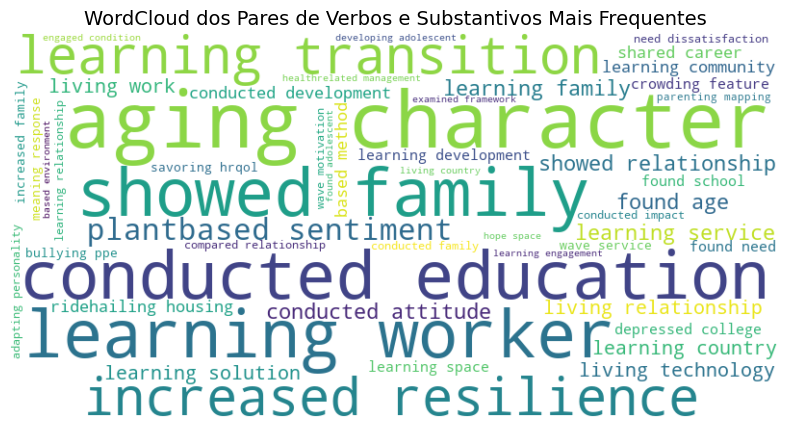

In [126]:
# Identificar os pares de verbos e substantivos
verb_noun_pairs = list(zip(verb_words, noun_words))
verb_noun_freq = Counter(verb_noun_pairs)
top_verb_noun_freq = dict(verb_noun_freq.most_common(50))

# Compactar os pares de verbos e substantivos
compact_freq = {f"{pair[0]} {pair[1]}": freq for pair, freq in top_verb_noun_freq.items()}

# WordCloud para os pares de verbos e substantivos
wordcloud_verb_noun = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(compact_freq)

# Exibir a WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_verb_noun, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud dos Pares de Verbos e Substantivos Mais Frequentes', fontsize=14)
plt.show()



# **5. Modelização**

## Dimensões Latentes - Tópicos

In [127]:
# Tokenizar o texto: Dividir o texto em uma lista de palavras
df_normalizado['Abstract_tokenized'] = df_normalizado['Abstract_Clean'].apply(lambda x: x.split())

# Criar o dicionário e o corpus
dictionary = Dictionary(df_normalizado['Abstract_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_normalizado['Abstract_tokenized']]

In [128]:
# Executar o modelo LDA
lda_model = LdaModel(corpus, num_topics=5 , id2word=dictionary, passes=15, random_state=42, alpha='auto',  per_word_topics=True) 

# Mostrar os tópicos
topics = lda_model.print_topics(num_words=8)
for topic in topics:
    print(f'Topic {topic[0]}: Words: {topic[1]}')

Topic 0: Words: 0.010*"age" + 0.010*"marital" + 0.009*"stress" + 0.009*"relationship" + 0.008*"sexual" + 0.008*"discrimination" + 0.008*"abuse" + 0.007*"work"
Topic 1: Words: 0.019*"anxiety" + 0.018*"depression" + 0.017*"stress" + 0.014*"youth" + 0.009*"caregivers" + 0.009*"community" + 0.009*"sensitivity" + 0.008*"engagement"
Topic 2: Words: 0.021*"work" + 0.016*"children" + 0.012*"pregnancy" + 0.010*"conflict" + 0.009*"family" + 0.008*"career" + 0.008*"relationship" + 0.007*"adolescents"
Topic 3: Words: 0.018*"learning" + 0.013*"school" + 0.010*"environment" + 0.009*"personality" + 0.008*"younger" + 0.007*"strengths" + 0.007*"happy" + 0.007*"emotions"
Topic 4: Words: 0.012*"adolescents" + 0.012*"school" + 0.012*"income" + 0.009*"religiosity" + 0.009*"predicted" + 0.007*"university" + 0.007*"motivation" + 0.007*"relationship"


In [129]:
# Cálculo do score de coerência
coherence_model_lda = CoherenceModel(model=lda_model, texts=df_normalizado['Abstract_tokenized'], dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()

# Exibir o resultado
print(f'Coherence Score: {coherence_score}')


Coherence Score: 0.4352959457469311


In [130]:
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

In [131]:
def get_document_topics(doc_bow):
    doc_topics = lda_model.get_document_topics(doc_bow)
    return [topic_prob for topic_id, topic_prob in doc_topics]

df_normalizado['document_topics'] = df_normalizado['Abstract_tokenized'].apply(lambda x: dictionary.doc2bow(x)).apply(get_document_topics) 

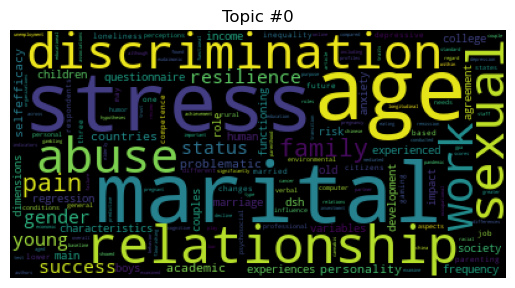

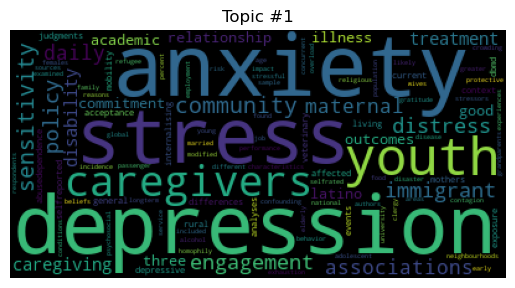

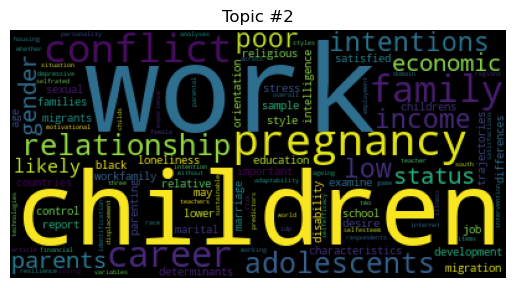

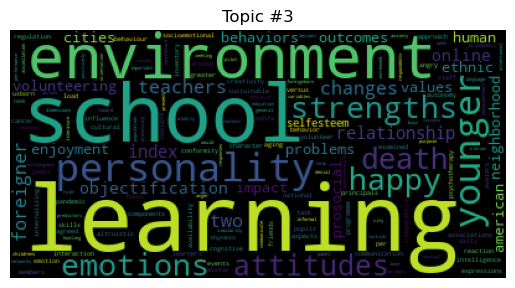

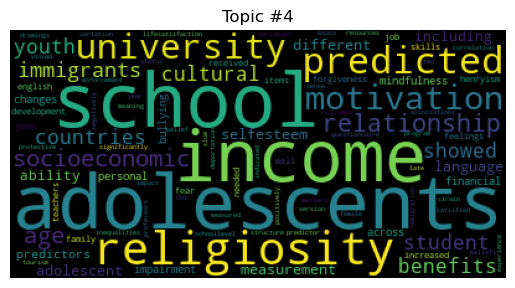

In [132]:
for t in range(lda_model.num_topics):
    plt.figure()
    plt.imshow(WordCloud().fit_words(dict(lda_model.show_topic(t, 200))))
    plt.axis("off")
    plt.title("Topic #" + str(t))
    plt.show()

# **6. Clusterização**

## 6.1. Determinar a matriz de distribuição de tópicos

In [133]:
# Obter a distribuição de tópicos para cada documento
topic_distributions = []
for bow in corpus:
    topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
    topic_distributions.append([prob for _, prob in topic_distribution])

# Converter para um array NumPy
topic_matrix = np.array(topic_distributions)

# Exibir a matriz de tópicos (linhas = documentos, colunas = tópicos)
print("Matriz de Distribuições de Tópicos (primeiros 5 documentos):\n")
print(topic_matrix[:5])

Matriz de Distribuições de Tópicos (primeiros 5 documentos):

[[2.5528187e-03 8.2032904e-02 2.4285738e-03 1.6862528e-03 9.1129947e-01]
 [2.0986123e-03 1.5182279e-03 2.7181691e-01 1.3862597e-03 7.2318000e-01]
 [3.3583817e-01 1.1673409e-01 3.1001347e-01 2.3552684e-01 1.8874797e-03]
 [7.0379698e-04 5.0914352e-04 6.6953304e-04 4.6488742e-04 9.9765265e-01]
 [2.8138091e-03 4.7034505e-01 2.6768174e-03 5.2189404e-01 2.2703425e-03]]


## 6.2. Determinar o Número de Clusters

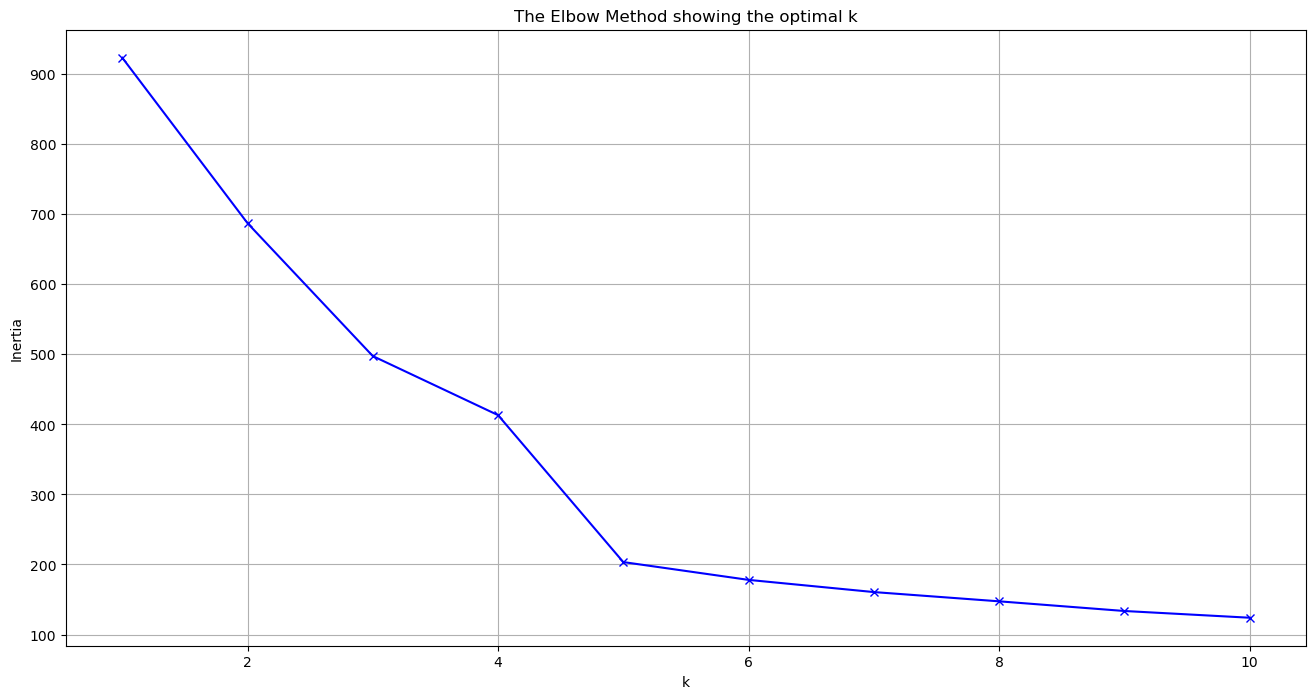

In [134]:
# Elbow Method
inertia = []
K = range(1, 11)  # Assuming we want to check for up to 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(topic_matrix)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(16, 8))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()

In [135]:
k_optimal=5

## 6.3. Clusterização a partir dos tópicos

In [136]:
kmeans = KMeans(n_clusters=k_optimal, n_init=10)
clusters = kmeans.fit_predict(topic_matrix)
df['Cluster'] = clusters

In [137]:
for i in range(k_optimal):
    print(f"Cluster {i}:")
    print(df_normalizado[df['Cluster'] == i]['Abstract_tokenized'])

Cluster 0:
11      [different, displacement, earthquake, three, d...
14      [return, migration, intentions, future, return...
21      [fiis, financial, stress, financial, whether, ...
23      [overall, dental, objectives, dental, objectiv...
25      [worklife, balance, wlb, workers, disabilities...
                              ...                        
2143    [predictors, career, adaptability, development...
2145    [attitudes, toward, marriage, children, indica...
2152    [death, disease, load, selfrated, personality,...
2157    [article, expectations, future, relatively, po...
2158    [fertility, countries, children, contextual, f...
Name: Abstract_tokenized, Length: 570, dtype: object
Cluster 1:
0       [china, policy, birth, relationship, sibling, ...
1       [financial, situation, literature, income, fin...
3       [influencing, transition, nonuse, tobacco, nic...
7       [mainland, china, hong, kong, crossborder, hon...
22      [motivation, instructors, impact, language, mo.

## 6.4. Distribuição de tópicos por cluster

In [138]:
# Agora, calcule a média das distribuições de tópicos para cada cluster
# Reset the index of the DataFrame to ensure proper alignment
df_reset = df.reset_index(drop=True)

# A média das distribuições de tópicos para cada cluster
topic_distributions_per_cluster = df_reset.groupby('Cluster', group_keys=False).apply(
    lambda group: topic_matrix[group.index].mean(axis=0)
)

# Convertendo a matriz para um DataFrame para uma visualização mais fácil
topic_distributions_per_cluster_df = pd.DataFrame(
    topic_distributions_per_cluster.tolist(),
    columns=[f'Topic {i+1}' for i in range(topic_matrix.shape[1])],
    index=[f'Cluster {i}' for i in range(k_optimal)]
)

# Visualizar as distribuições de tópicos por cluster
topic_distributions_per_cluster_df

C:\Users\clour\AppData\Local\Temp\ipykernel_16940\277111803.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  topic_distributions_per_cluster = df_reset.groupby('Cluster').apply(


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
Cluster 0,0.091989,0.057383,0.731006,0.050096,0.069526
Cluster 1,0.073051,0.058593,0.060654,0.058503,0.749199
Cluster 2,0.735173,0.060096,0.075569,0.059331,0.069831
Cluster 3,0.102556,0.681657,0.073036,0.052966,0.089785
Cluster 4,0.087047,0.056347,0.079399,0.699678,0.077529


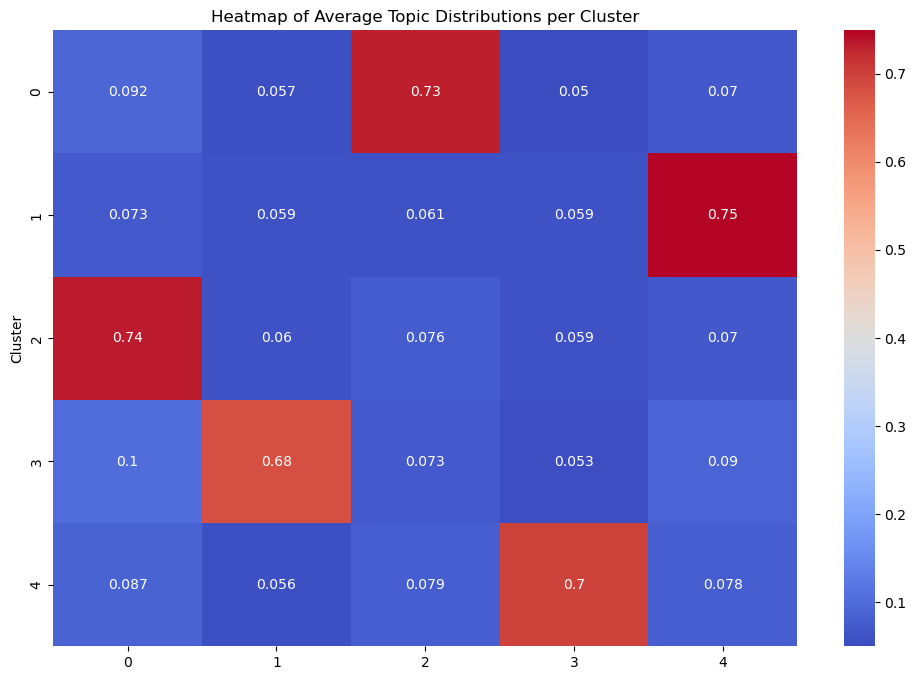

In [139]:
# Criar um DataFrame a partir da matriz de distribuição de tópicos e rótulos de cluster
topic_df = pd.DataFrame(topic_matrix)
topic_df['Cluster'] = clusters

# Calcular a média das distribuições de tópicos para cada cluster
cluster_means = topic_df.groupby('Cluster').mean()

# Criar o heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')
plt.title('Heatmap of Average Topic Distributions per Cluster')
plt.show()

## 6.5. Palavras mais frequentes por cluster

In [140]:
# Fixar a seed para reprodutibilidade
np.random.seed(42)

# Dicionário para armazenar palavras e frequências por cluster
cluster_words = {i: [] for i in range(k_optimal)}

# Analisar as palavras mais frequentes em cada cluster
for i in range(k_optimal):
    cluster_df = df_normalizado[df['Cluster'] == i]
    all_text = " ".join([" ".join(tokens) for tokens in cluster_df['Abstract_tokenized']])
    words = all_text.split()
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(10)
    
    # Adicionar palavras mais frequentes ao dicionário
    cluster_words[i] = [f"{word} ({freq})" for word, freq in most_common_words]

# Criar um DataFrame com os clusters como colunas
max_len = max(len(words) for words in cluster_words.values())  # Garantir que todas as colunas tenham o mesmo número de linhas
cluster_table = {f"Cluster {i}": cluster_words[i] + [""] * (max_len - len(cluster_words[i])) for i in cluster_words}

results_df = pd.DataFrame(cluster_table)

# Imprimir a tabela formatada
results_df


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
0,work (310),adolescents (157),relationship (210),depression (145),learning (131)
1,children (215),school (153),age (199),anxiety (141),school (128)
2,relationship (174),income (98),family (152),stress (129),online (78)
3,teachers (140),age (97),job (142),youth (99),values (77)
4,family (136),relationship (96),stress (131),service (70),pandemic (73)
5,education (133),tourism (95),children (111),rural (69),covid19 (69)
6,job (126),cultural (93),gender (110),relationship (68),relationship (60)
7,career (118),university (90),school (108),caregivers (67),behavior (60)
8,gender (116),countries (90),resilience (104),community (62),emotion (57)
9,age (112),predicted (78),work (100),countries (60),impact (56)


## 6.6. Número de documentos por cluster

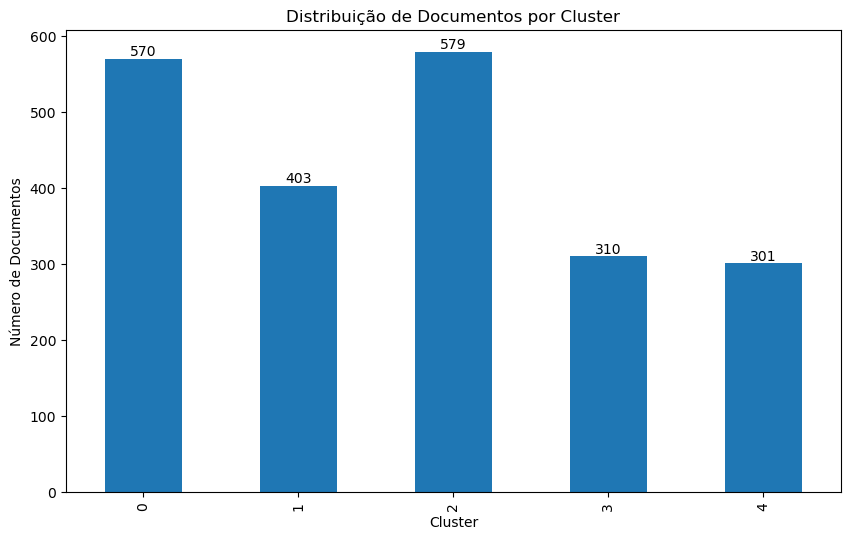

In [141]:
# Exibir a distribuição de documentos por cluster
plt.figure(figsize=(10, 6))
df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição de Documentos por Cluster')
plt.xlabel('Cluster')

# Adicionar a frequência de palavras em cima de cada barra
for i, count in enumerate(df['Cluster'].value_counts().sort_index()):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.ylabel('Número de Documentos')
plt.show()


## 6.7. Visualização dos clusters em 2D com PCA

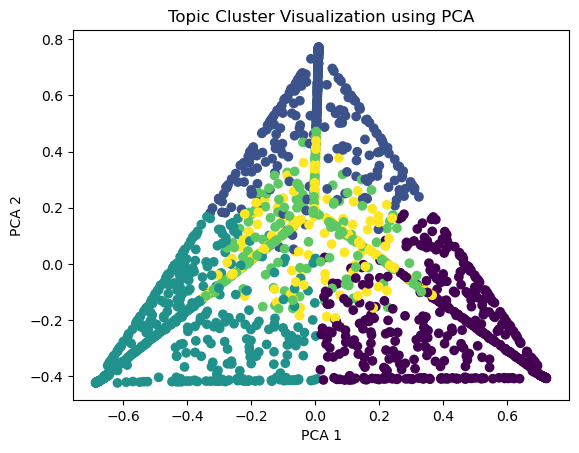

In [142]:
# PCA para redução de dimensionalidade
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(topic_matrix)

# Visualização dos clusters
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=clusters)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Topic Cluster Visualization using PCA')
plt.show()

In [143]:
print(corpus[:5])

[[(0, 2), (1, 2), (2, 3), (3, 2), (4, 2), (5, 3), (6, 2), (7, 2), (8, 3), (9, 5), (10, 6)], [(5, 4), (11, 4), (12, 2), (13, 3), (14, 2), (15, 2), (16, 3), (17, 2), (18, 2), (19, 4), (20, 2), (21, 2), (22, 7)], [(23, 2), (24, 2), (25, 6), (26, 2), (27, 2), (28, 3), (29, 2), (30, 2), (31, 4), (32, 2), (33, 2), (34, 6)], [(35, 3), (36, 3), (37, 3), (38, 2), (39, 7), (40, 4), (41, 7), (42, 2), (43, 2), (44, 4), (45, 3), (46, 3), (47, 2), (48, 2), (49, 9), (50, 2), (51, 3), (52, 6), (53, 3), (54, 2), (55, 2), (56, 2), (57, 2), (58, 3), (59, 3), (60, 3), (61, 2), (62, 3), (63, 2), (64, 2), (65, 4), (66, 10), (67, 2), (68, 2), (69, 3)], [(70, 2), (71, 5), (72, 7), (73, 2), (74, 2), (75, 4), (76, 3), (77, 4)]]


# **7. Abordagens adicionais**

## 7.1. Determinar o tópico dominante por documento

In [144]:
# Obter as distribuições de tópicos para cada documento
document_topic_distributions = [lda_model.get_document_topics(doc) for doc in corpus]


In [145]:
# Determinar o tópico dominante para cada documento
df_normalizado['Dominant_Topic'] = [max(topics, key=lambda x: x[1])[0] for topics in document_topic_distributions]

# Exibir os primeiros resultados
print(df_normalizado[['Abstract_Expanded', 'Dominant_Topic']].head())


                                   Abstract_Expanded  Dominant_Topic
0  china policy birth relationship sibling size c...               4
1  financial situation literature income financia...               4
2  love complex human capacity love capacity comp...               0
3  influencing transition nonuse tobacco nicotine...               4
4  community government openness community govern...               3


## 7.2. Pesquisa por tópico dominante 

In [146]:
# Obter documentos que têm como tópico dominante o tópico X
def buscar_por_topico(topic_id):
    return df_normalizado[df_normalizado['Dominant_Topic'] == topic_id][['Title', 'Dominant_Topic']]

# Exemplo: Obter documentos do Tópico 2
resultado = buscar_por_topico(2)
resultado


,Title,Dominant_Topic
11,qualiy of life in displaced earthquake survivors,2
14,holding the door slightly open: germany's migr...,2
21,love after lockup: examining the role of marri...,2
23,well-being of undergraduate dental students: q...,2
24,happiness amidst the covid-19 pandemic in indo...,2
...,...,...
2143,career adaptability development in adolescence...,2
2145,the incompatibility of materialism and the des...,2
2152,personality and personal control make a differ...,2
2157,limited expectations? how 14-16-year-old norwe...,2


In [147]:
# Obter documentos que têm como tópico dominante o tópico X
def buscar_por_topico(topic_id):
    resultados = df_normalizado[df_normalizado['Dominant_Topic'] == topic_id][['Title', 'Dominant_Topic']]
    # Transformar o título para que a primeira letra de cada palavra fique em maiúscula
    resultados['Title'] = resultados['Title'].str.title()
    return resultados

# Exemplo: Obter documentos do Tópico 3
resultado = buscar_por_topico(3)
resultado


,Title,Dominant_Topic
4,How Does Government Intervention Affect Commun...,3
5,Assessment Of Subjective Well-Being Of Healthc...,3
10,Systematic Review On Attitudes Towards Death A...,3
15,International Retirement Migration For Japanes...,3
17,How Did You Perceive The Lifestyle Changes Cau...,3
...,...,...
2135,Attitudes Toward Younger And Older Adults: The...,3
2147,Assimilation Ideology And Situational Well-Bei...,3
2153,National Well-Being And International Sports E...,3
2156,The Examination Of The Factors Affecting The F...,3


## 7.3. Tendência dos tópicos ao longo do tempo

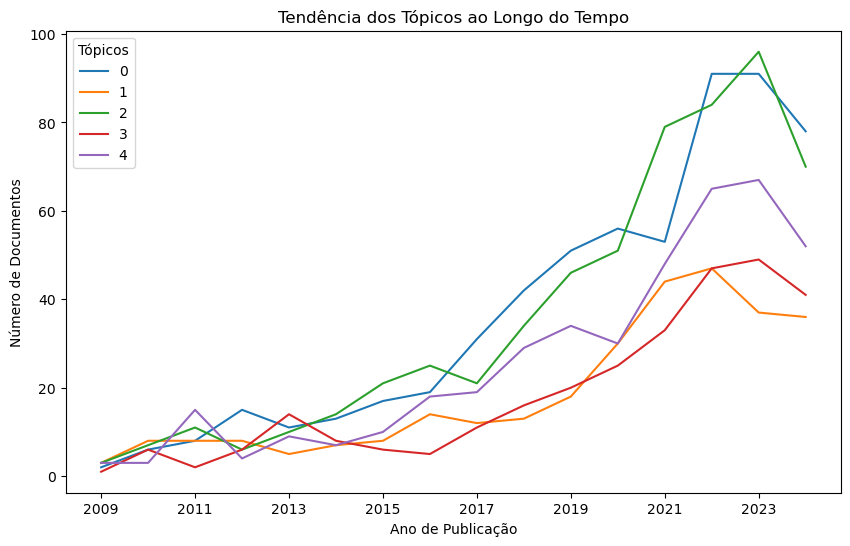

In [148]:
# Contar tópicos ao longo do tempo
topic_trends = df_normalizado.groupby(['Year', 'Dominant_Topic']).size().unstack(fill_value=0)
topic_trends.plot(kind='line', figsize=(10, 6))
plt.title('Tendência dos Tópicos ao Longo do Tempo')
plt.xlabel('Ano de Publicação')
plt.ylabel('Número de Documentos')
plt.legend(title='Tópicos')
plt.show()


## 7.4. Análise de Sentimentos

In [149]:
# Análise de Sentimento dos Abstracts

# Função para calcular o sentimento de um texto
def calcular_sentimento(text):
    blob = TextBlob(text)
    return blob.sentiment

# Aplicar a função à coluna 'Abstract_Expanded'

df_normalizado['Sentiment'] = df_normalizado['Abstract_Expanded'].apply(calcular_sentimento)

# Exibir os resultados
df_normalizado[['Abstract_Expanded', 'Sentiment']].head()


,Abstract_Expanded,Sentiment
0,china policy birth relationship sibling size c...,"(0.0, 0.0)"
1,financial situation literature income financia...,"(0.0, 0.0)"
2,love complex human capacity love capacity comp...,"(0.05714285714285713, 0.3714285714285714)"
3,influencing transition nonuse tobacco nicotine...,"(0.0, 0.3)"
4,community government openness community govern...,"(0.0, 0.0)"


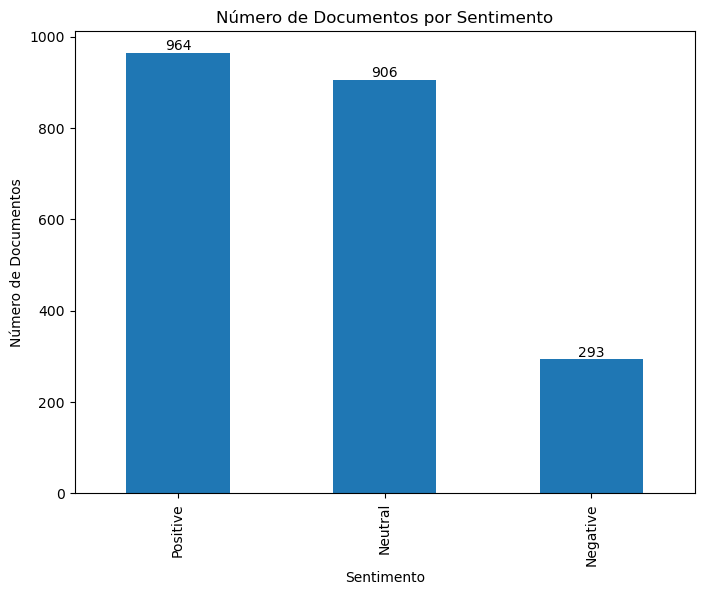

In [150]:
# Função para calcular o sentimento de um texto
def calcular_sentimento(text):
    blob = TextBlob(text)
    return blob.sentiment

# Aplicar a função à coluna 'Abstract_Expanded'
df_normalizado['Sentiment'] = df_normalizado['Abstract_Expanded'].apply(calcular_sentimento)

# Gráfico de barras que atribui aos sentimentos etiquetas de acordo com a polaridade
def label_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Aplicar a função à coluna 'Sentiment'
df_normalizado['Sentiment_Label'] = df_normalizado['Sentiment'].apply(lambda x: label_sentiment(x.polarity))

# Exibir os resultados
df_normalizado[['Abstract_Expanded', 'Sentiment', 'Sentiment_Label']].head()

# Contar o número de documentos por sentimento
sentiment_counts = df_normalizado['Sentiment_Label'].value_counts()

#Colocar o número de ocorrências em cada barra
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar')
plt.title('Número de Documentos por Sentimento')
plt.xlabel('Sentimento')
plt.ylabel('Número de Documentos')
for i, count in enumerate(sentiment_counts):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.show()
